In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataset import load_raw, get_feature_cols, TARGET_COL, SUBJECT_COL

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted")

df = load_raw()
feature_cols = get_feature_cols(df)

print(f"Shape: {df.shape}")
print(f"Features: {len(feature_cols)}")
df.head()

Shape: (5875, 22)
Features: 19


,age,test_time,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,sex,motor_UPDRS,total_UPDRS,subject#
0,72,5.6431,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006,0,28.199,34.398,1
1,72,12.6660,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810,0,28.447,34.894,1
2,72,19.6810,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014,0,28.695,35.389,1
3,72,25.6470,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277,0,28.905,35.810,1
4,72,33.6420,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361,0,29.187,36.375,1


In [2]:
df[feature_cols + [TARGET_COL]].describe().round(3)

,age,test_time,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,sex,total_UPDRS
count,5875.000,5875.000,5875.000,5875.0,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000
mean,64.805,92.864,0.006,0.0,0.003,0.003,0.009,0.034,0.311,0.017,0.020,0.027,0.051,0.032,21.679,0.541,0.653,0.220,0.318,29.019
std,8.822,53.446,0.006,0.0,0.003,0.004,0.009,0.026,0.230,0.013,0.017,0.020,0.040,0.060,4.291,0.101,0.071,0.091,0.466,10.700
min,36.000,-4.262,0.001,0.0,0.000,0.000,0.001,0.003,0.026,0.002,0.002,0.002,0.005,0.000,1.659,0.151,0.514,0.022,0.000,7.000
25%,58.000,46.848,0.004,0.0,0.002,0.002,0.005,0.019,0.175,0.009,0.011,0.016,0.028,0.011,19.406,0.470,0.596,0.156,0.000,21.371
50%,65.000,91.523,0.005,0.0,0.002,0.002,0.007,0.028,0.253,0.014,0.016,0.023,0.041,0.018,21.920,0.542,0.644,0.206,0.000,27.576
75%,72.000,138.445,0.007,0.0,0.003,0.003,0.010,0.040,0.365,0.021,0.024,0.033,0.062,0.031,24.444,0.614,0.711,0.264,1.000,36.399
max,85.000,215.490,0.100,0.0,0.058,0.070,0.173,0.269,2.107,0.163,0.167,0.275,0.488,0.748,37.875,0.966,0.866,0.732,1.000,54.992


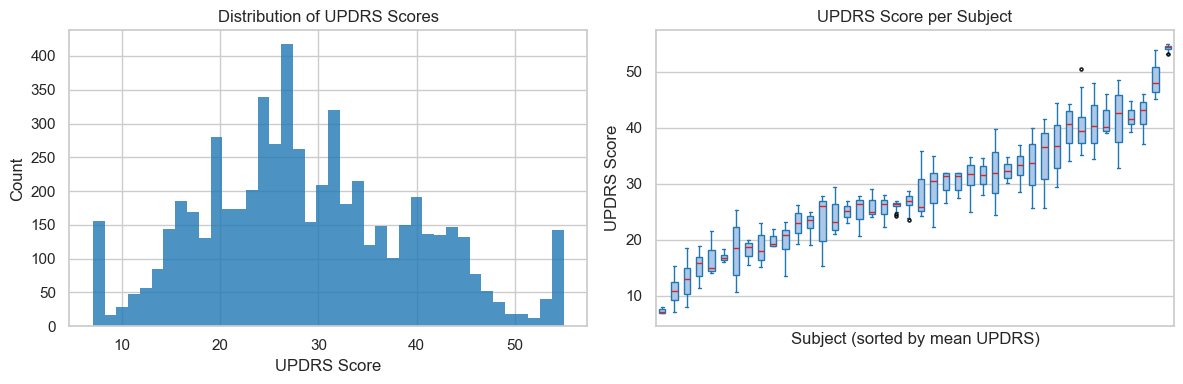

Saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df[TARGET_COL], bins=40, color='#1f77b4', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('UPDRS Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of UPDRS Scores')

# Per subject boxplot
subject_means = df.groupby(SUBJECT_COL)[TARGET_COL].mean().sort_values()
axes[1].boxplot(
    [df[df[SUBJECT_COL]==s][TARGET_COL].values for s in subject_means.index],
    patch_artist=True,
    boxprops=dict(facecolor='#aec7e8', color='#1f77b4'),
    medianprops=dict(color='#d62728'),
    whiskerprops=dict(color='#1f77b4'),
    capprops=dict(color='#1f77b4'),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
axes[1].set_xlabel('Subject (sorted by mean UPDRS)')
axes[1].set_ylabel('UPDRS Score')
axes[1].set_title('UPDRS Score per Subject')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../results/figures/eda_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")

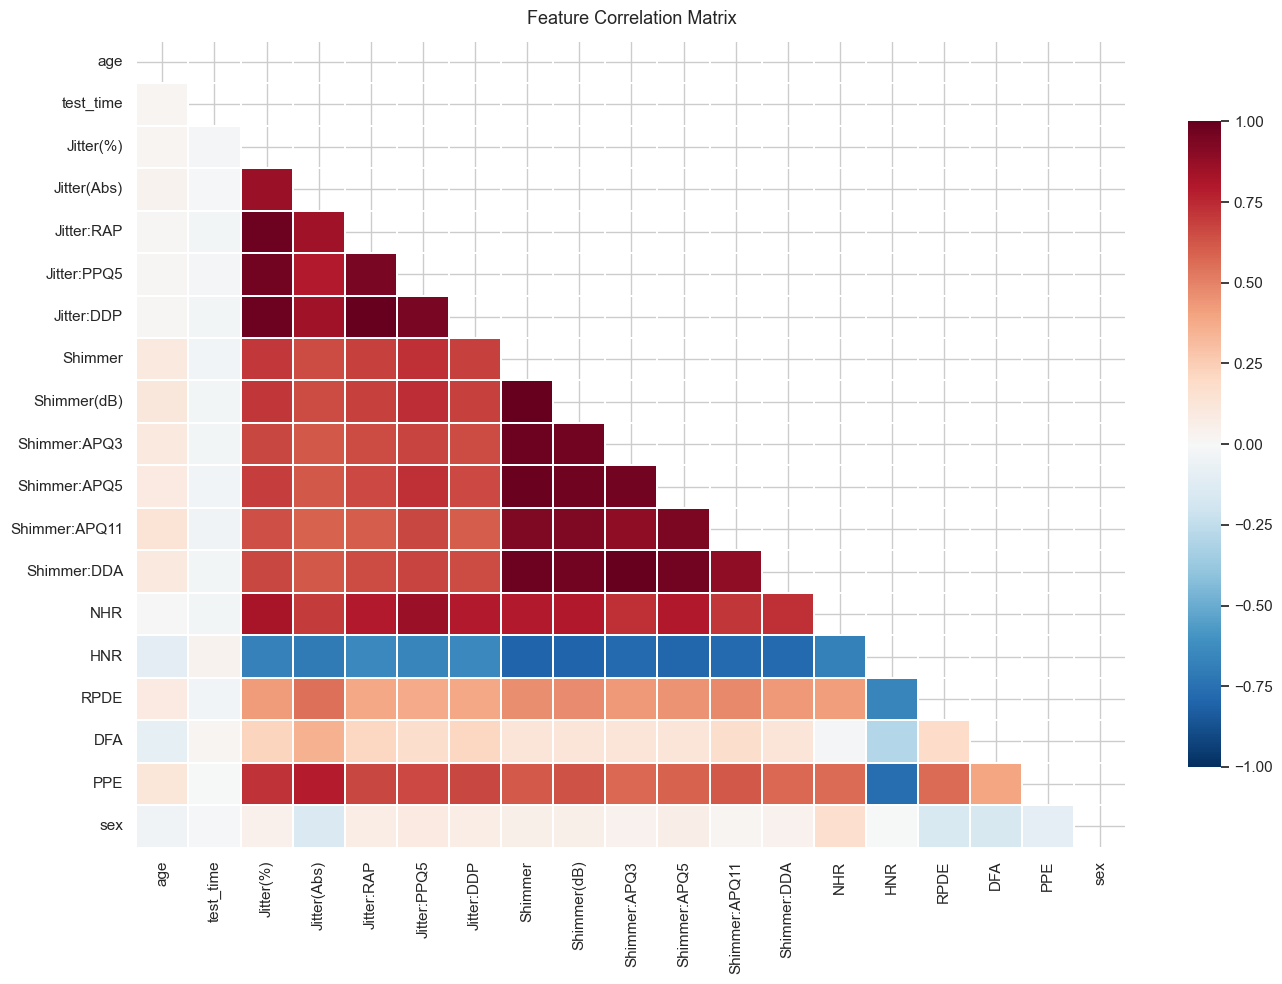

Saved.


In [4]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot=False,
    cbar_kws={"shrink": 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../results/figures/eda_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")

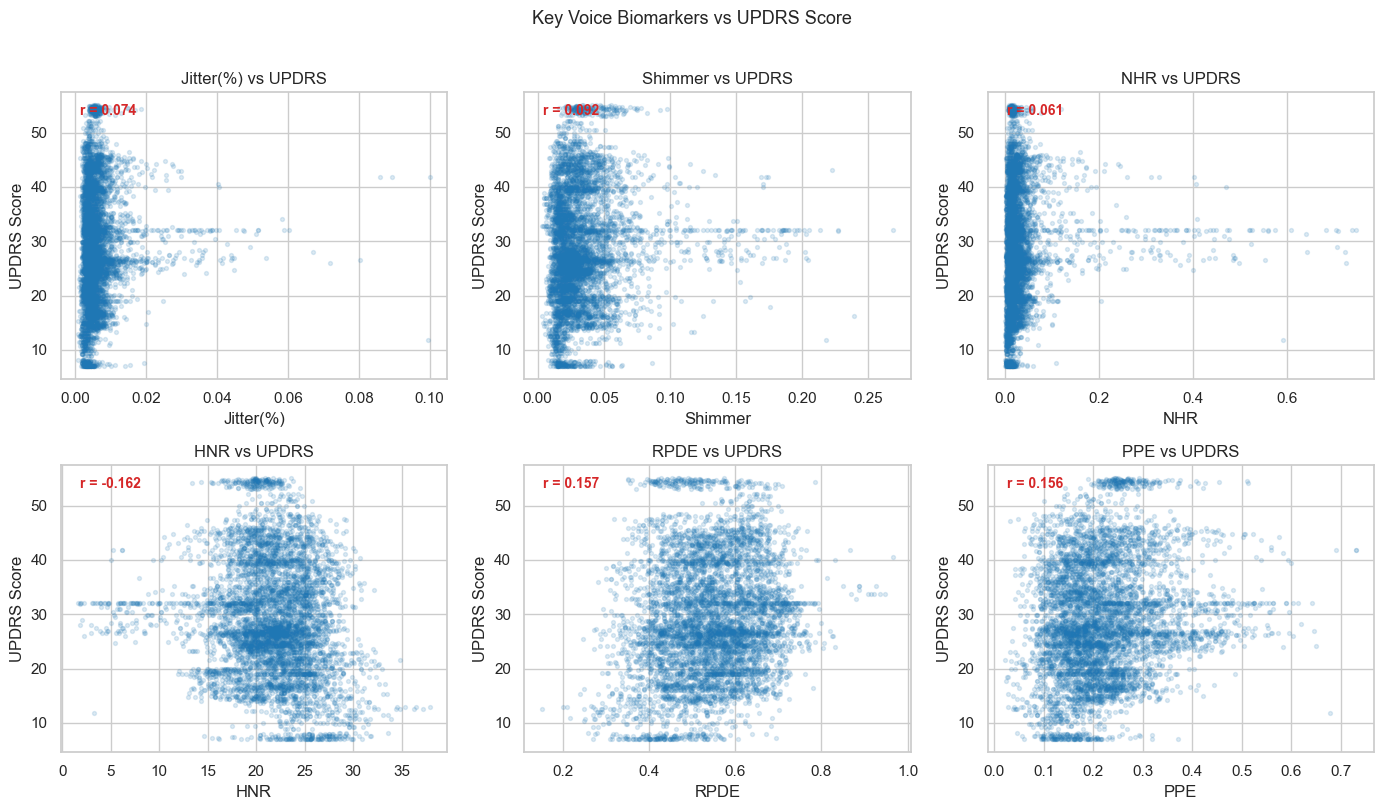

Saved.


In [5]:
top_features = ['Jitter(%)', 'Shimmer', 'NHR', 'HNR', 'RPDE', 'PPE']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df[TARGET_COL], alpha=0.15, s=8, color='#1f77b4')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('UPDRS Score')
    axes[i].set_title(f'{feat} vs UPDRS')
    # Add correlation coefficient
    corr = df[feat].corr(df[TARGET_COL])
    axes[i].text(0.05, 0.92, f'r = {corr:.3f}',
                 transform=axes[i].transAxes, fontsize=10,
                 color='#d62728', fontweight='bold')

plt.suptitle('Key Voice Biomarkers vs UPDRS Score', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/eda_feature_vs_updrs.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")